# Bài toán: Phân loại Traffic Level

## Mục đích
- Phân loại mức độ giao thông của chuyến đi thành 3 nhãn: low, medium, high
- Tạo nhãn từ chỉ số `traffic_index = trip_duration / trip_distance`
- Không dùng `trip_duration` làm feature để tránh data leakage
- So sánh chỉ 3 mô hình ML và chọn mô hình tốt nhất

## Ghi chú
- Chưa dùng `location_cluster` và `behavior_cluster` vì đây là các đầu ra của bài toán khác
- Notebook này sẽ chỉ dùng các đặc trưng có sẵn từ lộ trình và khoảng cách

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

sns.set_theme(style='whitegrid')

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## 2. Load và làm sạch dữ liệu

In [2]:
# Load raw taxi data
df = pd.read_csv('../data/processed/yellow_tripdata_2016-03_processed.csv')

df.head()


,Unnamed: 0,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,fare_amount,...,time_of_day,is_peak_hour,is_credit_card,total_income,location_cluster,fare_per_miles,fare_per_min,traffic_index,traffic_level,behavior_cluster
0,0,2016-03-01 00:00:00,2016-03-01 00:07:55,1,2.50,-73.976746,40.765152,-74.004265,40.746128,9.0,...,night,0,1,11.05,0,3.600000,1.136842,189.999924,0,2
1,1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,2.90,-73.983482,40.767925,-74.005943,40.733166,11.0,...,night,0,1,14.05,0,3.793103,0.990991,229.655093,0,2
2,2,2016-03-01 00:00:01,2016-03-01 00:16:04,1,6.20,-73.788773,40.647758,-73.829208,40.712345,20.5,...,night,0,0,20.50,-1,3.306452,1.277259,155.322556,0,1
3,3,2016-03-01 00:00:01,2016-03-01 00:05:00,1,0.70,-73.958221,40.764641,-73.967896,40.762901,5.5,...,night,0,1,7.50,0,7.857143,1.103679,427.142247,2,0
4,4,2016-03-01 00:00:01,2016-03-01 00:24:06,3,7.18,-73.985779,40.741192,-73.946350,40.797878,23.5,...,night,0,1,26.70,0,3.272981,0.975779,201.253454,0,1


In [3]:
df = df.drop(columns=['traffic_index', 'Unnamed: 0'], errors='ignore')

df.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,fare_amount,trip_duration,...,pickup_month,time_of_day,is_peak_hour,is_credit_card,total_income,location_cluster,fare_per_miles,fare_per_min,traffic_level,behavior_cluster
0,2016-03-01 00:00:00,2016-03-01 00:07:55,1,2.50,-73.976746,40.765152,-74.004265,40.746128,9.0,475.0,...,3,night,0,1,11.05,0,3.600000,1.136842,0,2
1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,2.90,-73.983482,40.767925,-74.005943,40.733166,11.0,666.0,...,3,night,0,1,14.05,0,3.793103,0.990991,0,2
2,2016-03-01 00:00:01,2016-03-01 00:16:04,1,6.20,-73.788773,40.647758,-73.829208,40.712345,20.5,963.0,...,3,night,0,0,20.50,-1,3.306452,1.277259,0,1
3,2016-03-01 00:00:01,2016-03-01 00:05:00,1,0.70,-73.958221,40.764641,-73.967896,40.762901,5.5,299.0,...,3,night,0,1,7.50,0,7.857143,1.103679,2,0
4,2016-03-01 00:00:01,2016-03-01 00:24:06,3,7.18,-73.985779,40.741192,-73.946350,40.797878,23.5,1445.0,...,3,night,0,1,26.70,0,3.272981,0.975779,0,1


## 3. Tạo nhãn traffic_level

In [7]:
# traffic_index phản ánh mức độ ùn tắc: thời gian trên mỗi dặm
df['traffic_index'] = df['trip_duration'] / (df['trip_distance'] + 1e-6)

low = df['traffic_index'].quantile(0.33)
high = df['traffic_index'].quantile(0.66)

def label_traffic(x):
    if x < low:
        return 0  # low traffic
    elif x < high:
        return 1  # medium traffic
    else:
        return 2  # high traffic

df['traffic_level'] = df['traffic_index'].apply(label_traffic)

print('✅ traffic_level created')
print(f'Low threshold  : {low:.2f}')
print(f'High threshold : {high:.2f}')
print('\nTraffic level distribution:')
print(df['traffic_level'].value_counts().sort_index())
print(f'\nClass ratio:')
print(df['traffic_level'].value_counts(normalize=True).sort_index().apply(lambda x: f'{x:.2%}'))

✅ traffic_level created
Low threshold  : 279.13
High threshold : 447.83

Traffic level distribution:
traffic_level
0    32473
1    32472
2    33458
Name: count, dtype: int64

Class ratio:
traffic_level
0    33.00%
1    33.00%
2    34.00%
Name: proportion, dtype: object


## 4. Phân tích nhanh nhãn

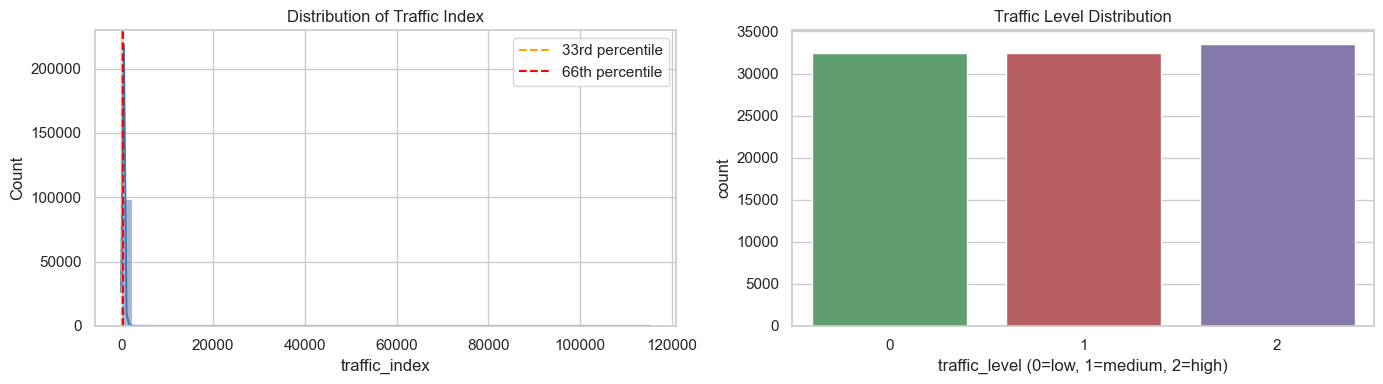

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['traffic_index'], bins=50, kde=True, ax=axes[0], color='#4C72B0')
axes[0].axvline(low, color='orange', linestyle='--', label='33rd percentile')
axes[0].axvline(high, color='red', linestyle='--', label='66th percentile')
axes[0].set_title('Distribution of Traffic Index')
axes[0].legend()

sns.countplot(x='traffic_level', data=df, ax=axes[1], palette=['#55A868', '#C44E52', '#8172B2'])
axes[1].set_title('Traffic Level Distribution')
axes[1].set_xlabel('traffic_level (0=low, 1=medium, 2=high)')

plt.tight_layout()
plt.show()

## 5. Chọn features

Chưa dùng `location_cluster` và `behavior_cluster` ở giai đoạn này.
Không dùng `trip_duration` để tránh leakage.

In [20]:
feature_cols = [
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'trip_distance',
    'location_cluster',
    'pickup_hour',
    'behavior_cluster',
    'fare_per_miles'
]

X = df[feature_cols].copy()
y = df['traffic_level'].copy()

print(f'Features used: {feature_cols}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

Features used: ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'trip_distance', 'location_cluster', 'pickup_hour', 'behavior_cluster', 'fare_per_miles']
X shape: (11411918, 9)
y shape: (11411918,)


## 6. Train/Test Split và scaling

In [21]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

feature_scales = [
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'trip_distance',
    'fare_per_miles',
]

scaler = StandardScaler()
X_train[feature_scales] = scaler.fit_transform(X_train[feature_scales])
X_val[feature_scales] = scaler.transform(X_val[feature_scales])
X_test[feature_scales] = scaler.transform(X_test[feature_scales])

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f"Train class ratio:\n{y_train.value_counts(normalize=True).sort_index()}")
print(f"Test class ratio:\n{y_test.value_counts(normalize=True).sort_index()}")
print(f"Validation class ratio:\n{y_val.value_counts(normalize=True).sort_index()}")

Train: (7988342, 9) | Test: (1711788, 9)
Train class ratio:
traffic_level
0    0.329964
1    0.330033
2    0.340003
Name: proportion, dtype: float64
Test class ratio:
traffic_level
0    0.329964
1    0.330033
2    0.340003
Name: proportion, dtype: float64
Validation class ratio:
traffic_level
0    0.329965
1    0.330033
2    0.340002
Name: proportion, dtype: float64


## 7. Lựa chọn mô hình

Tiêu chí lựa chọn mô hình là phải hoạt động tốt trên dữ liệu lớn của taxi dataset với hiệu suất cao và thời gian train nhanh chóng.

1. **LightGBM**: Mô hình boosting tối ưu cho dữ liệu lớn, có tốc độ train nhanh và xử lý tốt các quan hệ phi tuyến trong dữ liệu taxi.
2. **CatBoost**: Mô hình boosting mạnh trong xử lý các feature dạng categorical và có khả năng giảm overfitting tốt.
3. **XGBoost**: Mô hình boosting phổ biến với độ chính xác cao và khả năng học tốt các mối quan hệ phức tạp trong dữ liệu.

In [22]:
models = {
    'LightGBM': (LGBMClassifier(random_state=42, n_jobs=-1, device="gpu"), False),
    'CatBoost': (CatBoostClassifier(random_state=42, verbose=False, devices="0", task_type='GPU'), False),
    'XGBoost': (XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss', tree_method='hist', device='gpu'), False)
}

print(f'✅ {len(models)} models ready')

✅ 3 models ready


## 8. Training và đánh giá

In [23]:
results = {}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, (model, needs_scaling) in models.items():
    print(f'Training {name}...')

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    results[name] = {
        'model': model,
        'scaled': needs_scaling,
        'accuracy': accuracy_score(y_val, y_pred),
        'precision_macro': precision_score(y_val, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_val, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_val, y_pred, average='macro', zero_division=0),
        'y_pred': y_pred
    }

    # cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_weighted', n_jobs=1)
    # results[name]['cv_f1_weighted_mean'] = cv_scores.mean()
    # results[name]['cv_f1_weighted_std'] = cv_scores.std()

    print(f"  Accuracy: {results[name]['accuracy']:.4f}")
    print(f"  Precision: {results[name]['precision_macro']:.4f}")
    print(f"  Recall: {results[name]['recall_macro']:.4f}")
    print(f"  Weighted F1 : {results[name]['f1_macro']:.4f}")

    # print(f"  CV F1    : {results[name]['cv_f1_weighted_mean']:.4f} ± {results[name]['cv_f1_weighted_std']:.4f}")

print('✅ All models trained')

Training LightGBM...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1564
[LightGBM] [Info] Number of data points in the train set: 7988342, number of used features: 9
[LightGBM] [Info] Using GPU Device: Intel(R) UHD Graphics, Vendor: Intel(R) Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 8 dense feature groups (60.95 MB) transferred to GPU in 0.099820 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -1.108770
[LightGBM] [Info] Start training from score -1.108564
[LightGBM] [Info] Start training from score -1.078801
  Accuracy: 0.9289
  Precision: 0.9290
  Recall: 0.9286
  Weighted F1 : 0.9287
Training CatBoost...
  Accuracy: 0.9322
  Precision: 0.9322
  Recall: 0.9319
  Weighted F1 : 0.9320
Training XGBoost...
[19:57:22] WARNING: C:/Users/administrator/workspace/xgboost-win64_release_1.6.0/src/learn

## 9. So sánh kết quả 

In [24]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision Macro': [results[m]['precision_macro'] for m in results],
    'Recall Macro': [results[m]['recall_macro'] for m in results],
    'F1 Macro': [results[m]['f1_macro'] for m in results],
    # 'CV F1 Macro': [results[m]['cv_f1_macro_mean'] for m in results],
})

comparison_df = comparison_df.sort_values('F1 Macro', ascending=False).reset_index(drop=True)
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']

print('📊 Model comparison')
print(comparison_df.to_string(index=False))
print(f"\n🏆 Best model: {best_model_name}")

📊 Model comparison
   Model  Accuracy  Precision Macro  Recall Macro  F1 Macro
CatBoost  0.932157         0.932180      0.931902  0.932007
 XGBoost  0.930131         0.930218      0.929864  0.929993
LightGBM  0.928862         0.928966      0.928590  0.928726

🏆 Best model: CatBoost


## 10. Sử dụng Optuna để lấy tham số tốt nhất cho từng mô hình

In [14]:
import optuna

sample_size = 500000

sample_indices = np.random.choice(
    len(X_train),
    sample_size,
    replace=False
)

X_train_tune = X_train.iloc[sample_indices]
y_train_tune = y_train.iloc[sample_indices]

def objective_lgbm(trial):

    params = {
    'n_estimators': trial.suggest_int('n_estimators', 100, 300),
    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15),
    'max_depth': trial.suggest_int('max_depth', 4, 10),
    'num_leaves': trial.suggest_int('num_leaves', 20, 64),
    'subsample': trial.suggest_float('subsample', 0.7, 1.0),
    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),

    'min_child_samples': 20,
    'min_data_in_leaf': 20,

    'random_state': 42,
    'n_jobs': -1,

    'device': 'cpu'
}

    model = LGBMClassifier(**params)

    model.fit(X_train_tune, y_train_tune)

    y_pred = model.predict(X_val)

    accuracy = accuracy_score(y_val, y_pred)
    precision_macro = precision_score(y_val, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_val, y_pred, average='macro', zero_division=0)
    score = f1_score(y_val, y_pred, average='macro', zero_division=0)

    trial.set_user_attr("accuracy", accuracy)
    trial.set_user_attr("precision_macro", precision_macro)
    trial.set_user_attr("recall_macro", recall_macro)
    trial.set_user_attr("f1_macro", score)

    return score

# =====================================================
# XGBOOST
# =====================================================

def objective_xgb(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),

        'random_state': 42,
        'eval_metric': 'mlogloss',
        'tree_method': 'hist',
        'device': 'cuda'
    }

    model = XGBClassifier(**params)

    model.fit(X_train_tune, y_train_tune)

    y_pred = model.predict(X_val)

    accuracy = accuracy_score(y_val, y_pred)
    precision_macro = precision_score(y_val, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_val, y_pred, average='macro', zero_division=0)
    score = f1_score(y_val, y_pred, average='macro', zero_division=0)

    trial.set_user_attr("accuracy", accuracy)
    trial.set_user_attr("precision_macro", precision_macro)
    trial.set_user_attr("recall_macro", recall_macro)
    trial.set_user_attr("f1_macro", score)

    return score

    

# =====================================================
# CATBOOST
# =====================================================

def objective_cat(trial):

    params = {
        'iterations': trial.suggest_int('iterations', 100, 400),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),

        'random_state': 42,
        'verbose': False,
        'task_type': 'GPU',
        'devices': '0'
    }

    model = CatBoostClassifier(**params)

    model.fit(X_train_tune, y_train_tune)

    y_pred = model.predict(X_val)

    accuracy = accuracy_score(y_val, y_pred)
    precision_macro = precision_score(y_val, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_val, y_pred, average='macro', zero_division=0)
    score = f1_score(y_val, y_pred, average='macro', zero_division=0)

    trial.set_user_attr("accuracy", accuracy)
    trial.set_user_attr("precision_macro", precision_macro)
    trial.set_user_attr("recall_macro", recall_macro)
    trial.set_user_attr("f1_macro", score)

    return score

# =====================================================
# RUN OPTUNA
# =====================================================

print("=" * 50)
print("TUNING LIGHTGBM")
print("=" * 50)

study_lgbm = optuna.create_study(direction='maximize')

study_lgbm.optimize(objective_lgbm, n_trials=20)

print("Best LightGBM Score:", study_lgbm.best_value)
print("Best LightGBM Params:")
print(study_lgbm.best_params)
print("\nBest LightGBM Metrics:")
for key, value in study_lgbm.best_trial.user_attrs.items():
    print(f"  {key}: {value}")

# =====================================================

print("=" * 50)
print("TUNING XGBOOST")
print("=" * 50)

study_xgb = optuna.create_study(direction='maximize')

study_xgb.optimize(objective_xgb, n_trials=20)

print("Best XGBoost Score:", study_xgb.best_value)
print("Best XGBoost Params:")
print(study_xgb.best_params)
print("\nBest XGBoost Metrics:")
for key, value in study_xgb.best_trial.user_attrs.items():
    print(f"  {key}: {value}")

# =====================================================

print("=" * 50)
print("TUNING CATBOOST")
print("=" * 50)

study_cat = optuna.create_study(direction='maximize')

study_cat.optimize(objective_cat, n_trials=20)

print("Best CatBoost Score:", study_cat.best_value)
print("Best CatBoost Params:")
print(study_cat.best_params)
print("\nBest CatBoost Metrics:")
for key, value in study_cat.best_trial.user_attrs.items():
    print(f"  {key}: {value}")

[I 2026-05-11 17:27:37,539] A new study created in memory with name: no-name-424b816e-c75f-4bb8-b592-f10755622de4


TUNING LIGHTGBM
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007396 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1564
[LightGBM] [Info] Number of data points in the train set: 500000, number of used features: 9
[LightGBM] [Info] Start training from score -1.109263
[LightGBM] [Info] Start training from score -1.108669
[LightGBM] [Info] Start training from score -1.078222
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20


[I 2026-05-11 17:27:49,420] Trial 0 finished with value: 0.9284512476343337 and parameters: {'n_estimators': 218, 'learning_rate': 0.0776719161372534, 'max_depth': 8, 'num_leaves': 27, 'subsample': 0.8486120382279921, 'colsample_bytree': 0.7369353354156214}. Best is trial 0 with value: 0.9284512476343337.


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002022 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1564
[LightGBM] [Info] Number of data points in the train set: 500000, number of used features: 9
[LightGBM] [Info] Start training from score -1.109263
[LightGBM] [Info] Start training from score -1.108669
[LightGBM] [Info] Start training from score -1.078222
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20


[I 2026-05-11 17:27:58,991] Trial 1 finished with value: 0.9285997660691655 and parameters: {'n_estimators': 184, 'learning_rate': 0.1075375454343399, 'max_depth': 8, 'num_leaves': 28, 'subsample': 0.824263948388824, 'colsample_bytree': 0.8295170670373004}. Best is trial 1 with value: 0.9285997660691655.


...

[17:40:13] WARNING: C:/Users/administrator/workspace/xgboost-win64_release_1.6.0/src/learner.cc:627: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




[I 2026-05-11 17:40:42,025] Trial 19 finished with value: 0.9296047167253194 and parameters: {'n_estimators': 398, 'learning_rate': 0.09007606856103204, 'max_depth': 6, 'subsample': 0.6710105326416624, 'colsample_bytree': 0.8250549962419249}. Best is trial 16 with value: 0.9298096186619352.
[I 2026-05-11 17:40:42,026] A new study created in memory with name: no-name-6729772b-4395-404b-ba6c-b2b6e2ee3ff1


Best XGBoost Score: 0.9298096186619352
Best XGBoost Params:
{'n_estimators': 398, 'learning_rate': 0.060551909043809644, 'max_depth': 8, 'subsample': 0.6587128847114383, 'colsample_bytree': 0.8244193305097077}

Best XGBoost Metrics:
  accuracy: 0.9299241494858008
  precision_macro: 0.9300790357340888
  recall_macro: 0.9296634897599348
  f1_macro: 0.9298096186619352
TUNING CATBOOST


[I 2026-05-11 17:40:50,213] Trial 0 finished with value: 0.9287758226485611 and parameters: {'iterations': 267, 'learning_rate': 0.15882692935134837, 'depth': 8, 'l2_leaf_reg': 3.181364754859931}. Best is trial 0 with value: 0.9287758226485611.
[I 2026-05-11 17:40:57,441] Trial 1 finished with value: 0.9286782490488091 and parameters: {'iterations': 272, 'learning_rate': 0.18356828178687215, 'depth': 7, 'l2_leaf_reg': 7.2708877780397945}. Best is trial 0 with value: 0.9287758226485611.
[I 2026-05-11 17:41:08,643] Trial 2 finished with value: 0.928899613356743 and parameters: {'iterations': 231, 'learning_rate': 0.13225771653742088, 'depth': 10, 'l2_leaf_reg': 8.52396813954302}. Best is trial 2 with value: 0.928899613356743.
[I 2026-05-11 17:41:13,250] Trial 3 finished with value: 0.9231618499098864 and parameters: {'iterations': 189, 'learning_rate': 0.06925332393012076, 'depth': 5, 'l2_leaf_reg': 4.397297671643918}. Best is trial 2 with value: 0.928899613356743.
[I 2026-05-11 17:41:18

Best CatBoost Score: 0.9293963929610113
Best CatBoost Params:
{'iterations': 369, 'learning_rate': 0.1176444283517178, 'depth': 10, 'l2_leaf_reg': 8.87642134660512}

Best CatBoost Metrics:
  accuracy: 0.9295251514790382
  precision_macro: 0.9296601024782051
  recall_macro: 0.9292539884947676
  f1_macro: 0.9293963929610113


## 11. Sử dụng siêu tham số để dự đoán test set

In [ ]:
best_lightgbm = LGBMClassifier(**study_lgbm.best_params, random_state=42, n_jobs=-1, device="cpu")

best_xgb = XGBClassifier(**study_xgb.best_params, random_state=42, use_label_encoder=False, eval_metric='mlogloss', tree_method='hist', device='gpu')

best_cat = CatBoostClassifier(**study_cat.best_params, random_state=42, verbose=False, task_type='GPU', devices='0')

best_lightgbm.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)
best_cat.fit(X_train, y_train)

y_pred_lgbm = best_lightgbm.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)
y_pred_cat = best_cat.predict(X_test)

acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
acc_cat = accuracy_score(y_test, y_pred_cat)

precision_macro_lgbm = precision_score(y_test, y_pred_lgbm, average='macro', zero_division=0)
precision_macro_xgb = precision_score(y_test, y_pred_xgb, average='macro', zero_division=0)
precision_macro_cat = precision_score(y_test, y_pred_cat, average='macro', zero_division=0)

recall_macro_lgbm = recall_score(y_test, y_pred_lgbm, average='macro', zero_division=0)
recall_macro_xgb = recall_score(y_test, y_pred_xgb, average='macro', zero_division=0)
recall_macro_cat = recall_score(y_test, y_pred_cat, average='macro', zero_division=0)

f1_core_macro_lgbm = f1_score(y_test, y_pred_lgbm, average='macro', zero_division=0)
f1_core_macro_xgb = f1_score(y_test, y_pred_xgb, average='macro', zero_division=0)
f1_core_macro_cat = f1_score(y_test, y_pred_cat, average='macro', zero_division=0)



In [30]:
comparison_df = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost', 'CatBoost'],
    'Accuracy': [acc_lgbm, acc_xgb, acc_cat],
    'Precision Macro': [precision_macro_lgbm, precision_macro_xgb, precision_macro_cat],
    'Recall Macro': [recall_macro_lgbm, recall_macro_xgb, recall_macro_cat],
    'F1 Macro': [f1_core_macro_lgbm, f1_core_macro_xgb, f1_core_macro_cat],
}).sort_values('F1 Macro', ascending=False).reset_index(drop=True)

best_model_name = comparison_df.iloc[0]['Model']
best_model = {
    'LightGBM': best_lightgbm,
    'XGBoost': best_xgb,
    'CatBoost': best_cat
}[best_model_name]


print("Kết quả dự đoán trên tập test:")

print(comparison_df.to_string(index=False))
print(f"\n🏆Mô hình tốt nhất trên test set: {best_model_name}")


Kết quả dự đoán trên tập test:
   Model  Accuracy  Precision Macro  Recall Macro  F1 Macro
 XGBoost  0.931714         0.931782      0.931458  0.931577
CatBoost  0.931103         0.931120      0.930837  0.930943
LightGBM  0.930966         0.931053      0.930710  0.930835

🏆Mô hình tốt nhất trên test set: XGBoost


## 12. Confusion matrix và báo cáo chi tiết

### 12.1 Mô hình XGBoost

              precision    recall  f1-score   support

         low       0.95      0.93      0.94    564829
      medium       0.89      0.91      0.90    564946
        high       0.96      0.96      0.96    582013

    accuracy                           0.93   1711788
   macro avg       0.93      0.93      0.93   1711788
weighted avg       0.93      0.93      0.93   1711788



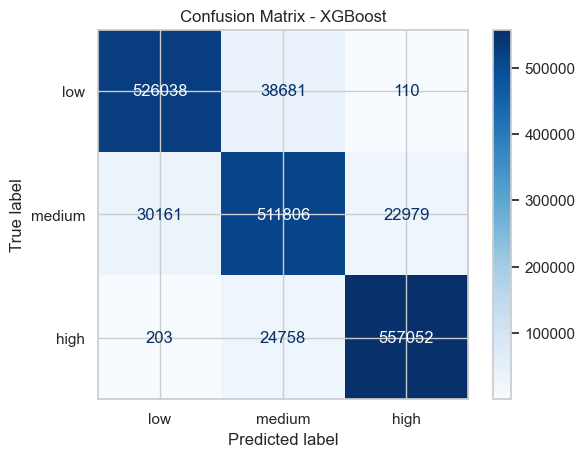

In [ ]:
print(classification_report(y_test, y_pred_xgb, target_names=['low', 'medium', 'high'], zero_division=0))

cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['low', 'medium', 'high'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

### 12.2 Mô hình CatBoost

              precision    recall  f1-score   support

         low       0.94      0.93      0.94    564829
      medium       0.89      0.90      0.90    564946
        high       0.96      0.96      0.96    582013

    accuracy                           0.93   1711788
   macro avg       0.93      0.93      0.93   1711788
weighted avg       0.93      0.93      0.93   1711788



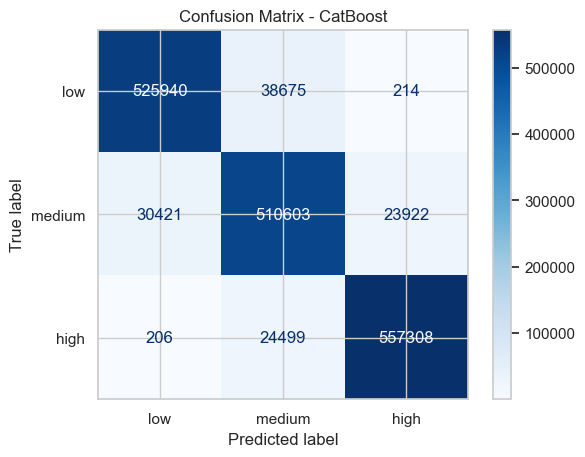

In [35]:
print(classification_report(y_test, y_pred_cat, target_names=['low', 'medium', 'high'], zero_division=0))

cm = confusion_matrix(y_test, y_pred_cat)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['low', 'medium', 'high'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - CatBoost')
plt.show()

### 12.3 Mô hình LightGBM

              precision    recall  f1-score   support

         low       0.94      0.93      0.94    564829
      medium       0.89      0.91      0.90    564946
        high       0.96      0.96      0.96    582013

    accuracy                           0.93   1711788
   macro avg       0.93      0.93      0.93   1711788
weighted avg       0.93      0.93      0.93   1711788



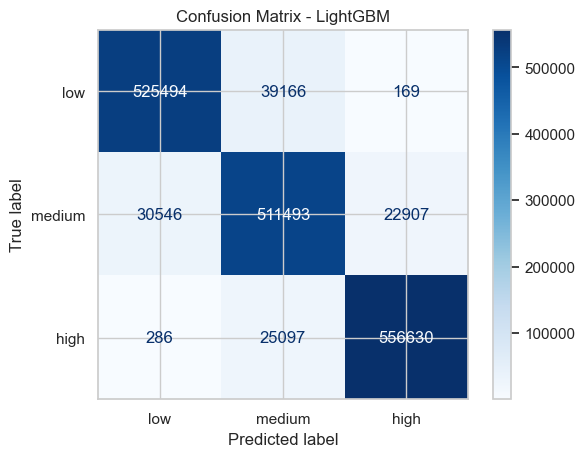

In [33]:
print(classification_report(y_test, y_pred_lgbm, target_names=['low', 'medium', 'high'], zero_division=0))

cm = confusion_matrix(y_test, y_pred_lgbm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['low', 'medium', 'high'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - LightGBM')
plt.show()

### Lưu các model

In [ ]:
import joblib

joblib.dump(best_xgb, './model/traffic/best_traffic_model.pkl')

joblib.dump(best_lightgbm, './model/traffic/best_lightgbm_traffic_model.pkl')

joblib.dump(best_cat, './model/traffic/best_catboost_traffic_model.pkl')

FileNotFoundError: [Errno 2] No such file or directory: 'model/traffic/best_traffic_model.pkl'

## 11. Dự đoán traffic_level cho toàn bộ dataset và lưu kết quả

In [ ]:
# Predict on full cleaned dataset
X_full = df[feature_cols].copy()
X_full[feature_scales] = scaler.transform(X_full[feature_scales])

df['predicted_traffic_level'] = best_model.predict(X_full)

print('✅ Full dataset predicted')
print(df[['traffic_level', 'predicted_traffic_level']].head())

output_path = '../data/raw/taxi_with_traffic_level.csv'
save_cols = [
    'tpep_pickup_datetime', 'tpep_dropoff_datetime',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'trip_distance', 'trip_duration',
    'traffic_index', 'traffic_level', 'predicted_traffic_level'
]
save_cols = [c for c in save_cols if c in df.columns]
df[save_cols].to_csv(output_path, index=False)
print(f'✅ Saved output to: {output_path}')

✅ Full dataset predicted
   traffic_level  predicted_traffic_level
0              0                        2
1              0                        1
2              0                        0
7              0                        0
8              1                        2
✅ Saved output to: ../data/raw/taxi_with_traffic_level.csv
